# Klasifikasi Kualitas Air Higiene Sanitasi — Dataset Water Potability (Kaggle)
### Random Forest | Studi Kasus: Sistem Monitoring Air Desa Sulahan, Bangli

Dataset sumber: **Water Potability Dataset** (Kaggle, adityakadiwal) — 3.276 sampel, 9 fitur asal.

Notebook ini mencakup: **1) Import Library → 2) Preprocessing → 3) EDA**
(Split data & training Random Forest menyusul di tahap berikutnya)


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Library siap.')


Library siap.


## 2. Memuat Dataset

> **Catatan Colab:** upload file `water_quality.csv` ke sesi Colab dulu
> (klik ikon folder di sidebar kiri → tombol upload), atau jalankan cell upload di bawah.


In [2]:
# Jika di Colab dan file belum ada di sesi, jalankan ini (hapus tanda # di bawah):
# from google.colab import files
# uploaded = files.upload()

df_raw = pd.read_csv('water_quality.csv')
print('Shape:', df_raw.shape)
df_raw.head()


Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


## 3. Preprocessing

### 3.1 Seleksi Kolom

Dataset asli berisi 9 fitur untuk kelayakan **air minum** (ph, Hardness, Solids, Chloramines,
Sulfate, Conductivity, Organic_carbon, Trihalomethanes, Turbidity) + label `Potability`.

Kita hanya ambil 3 kolom yang relevan dengan parameter IoT rancangan: `ph`, `Turbidity`, `Solids`
(sebagai proksi TDS). Kolom lain dan label `Potability` asli dibuang — label akan dibuat ulang
berbasis ambang SBMKL air higiene sanitasi, bukan standar air minum.

> Dataset ini **tidak memiliki kolom Suhu** sama sekali, jadi notebook ini hanya memakai 3 dari
> 4 parameter target risetmu.


In [4]:
df = df_raw[['ph', 'Turbidity', 'Solids']].copy()
df.columns = ['pH', 'Turbidity', 'TDS']
df.head()


,pH,Turbidity,TDS
0,NaN,2.963135,20791.31898
1,3.716080,4.500656,18630.05786
2,8.099124,3.055934,19909.54173
3,8.316766,4.628771,22018.41744
4,9.092223,4.075075,17978.98634


### 3.2 Cek Missing Value & Imputasi

In [5]:
print('Sebelum imputasi:')
print(df.isnull().sum())

# pH punya ~15% missing value -> imputasi median (umum dipakai untuk dataset ini di literatur)
df['pH'] = df['pH'].fillna(df['pH'].median())

print('\nSetelah imputasi median:')
print(df.isnull().sum())
print('\nTotal baris duplikat:', df.duplicated().sum())


Sebelum imputasi:
pH           491
Turbidity      0
TDS            0
dtype: int64

Setelah imputasi median:
pH           0
Turbidity    0
TDS          0
dtype: int64

Total baris duplikat: 0


### 3.3 PERIKSA SKALA KOLOM TDS — Temuan Penting

Sebelum membuat label, cek dulu apakah nilai `TDS` (dari kolom `Solids`) masuk akal secara satuan mg/L.


In [6]:
df['TDS'].describe()


count     3276.000000
mean     22014.092526
std       8768.570828
min        320.942611
25%      15666.690300
50%      20927.833605
75%      27332.762125
max      61227.196010
Name: TDS, dtype: float64

**Masalah ditemukan:** nilai `TDS` di dataset ini berkisar ±320 – 61.227, jauh di atas rentang
TDS air tawar yang wajar (umumnya puluhan hingga ribuan mg/L). Ini adalah kuirk yang sudah dikenal
luas pada dataset Kaggle Water Potability ini — skala kolom `Solids` tidak sepenuhnya konsisten
dengan pembacaan sensor TDS mg/L standar (SNI/APHA), kemungkinan karena metode
pembangkitan datanya.

**Konsekuensi bila threshold SBMKL (`TDS < 300`) tetap dipaksakan:** 100% baris akan otomatis
"gagal" TDS — kolom itu jadi tidak informatif untuk pelabelan.

**Keputusan metodologis:**
- Kolom `TDS` **tetap dipakai sebagai fitur input** model Random Forest (siapa tahu polanya masih
  punya nilai prediktif relatif, meski skalanya tidak match).
- Kolom `TDS` **tidak dipakai dalam aturan pelabelan** — label hanya berdasarkan `pH` dan
  `Turbidity`, dua parameter yang skalanya sudah sesuai satuan standar.
- Batasan ini perlu dicantumkan eksplisit di bagian Metode/Keterbatasan Penelitian nanti.


### 3.4 Pelabelan Berdasarkan SBMKL Permenkes No. 2 Tahun 2023 (Tabel 3)

Ambang batas yang dipakai (2 dari 3 kriteria, sesuai catatan di atas):
- pH: 6,5 – 8,5
- Kekeruhan (Turbidity): < 3 NTU

Aturan kategori:
- **Aman** — pH dan Turbidity keduanya dalam ambang
- **Perlu Perhatian** — tepat 1 parameter di luar ambang
- **Tidak Aman** — kedua parameter di luar ambang


In [7]:
def label_sbmkl(row):
    checks = [
        6.5 <= row['pH'] <= 8.5,
        row['Turbidity'] < 3
    ]
    gagal = checks.count(False)
    if gagal == 0:
        return 'Aman'
    elif gagal == 1:
        return 'Perlu Perhatian'
    else:
        return 'Tidak Aman'

df['Kategori'] = df.apply(label_sbmkl, axis=1)
df['Kategori'].value_counts()


Kategori
Perlu Perhatian    1784
Tidak Aman         1292
Aman                200
Name: count, dtype: int64

## 4. Exploratory Data Analysis (EDA)

### 4.1 Statistik Deskriptif

In [8]:
df.describe()


,pH,Turbidity,TDS
count,3276.000000,3276.000000,3276.000000
mean,7.074194,3.966786,22014.092526
std,1.470040,0.780382,8768.570828
min,0.000000,1.450000,320.942611
25%,6.277673,3.439711,15666.690300
50%,7.036752,3.955028,20927.833605
75%,7.870050,4.500320,27332.762125
max,14.000000,6.739000,61227.196010


### 4.2 Distribusi Kelas (Kategori SBMKL)

/tmp/ipykernel_514/3897459951.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Kategori', order=order, palette='mako')


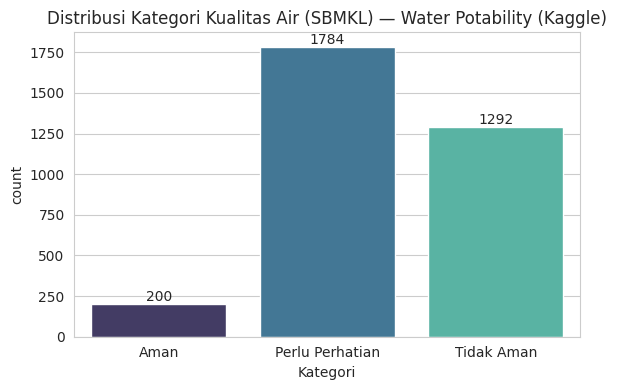

Kategori
Perlu Perhatian    54.5
Tidak Aman         39.4
Aman                6.1
Name: proportion, dtype: float64 %


In [9]:
plt.figure(figsize=(6,4))
order = ['Aman', 'Perlu Perhatian', 'Tidak Aman']
ax = sns.countplot(data=df, x='Kategori', order=order, palette='mako')
plt.title('Distribusi Kategori Kualitas Air (SBMKL) — Water Potability (Kaggle)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(df['Kategori'].value_counts(normalize=True).round(3) * 100, '%')


### 4.3 Distribusi Tiap Parameter

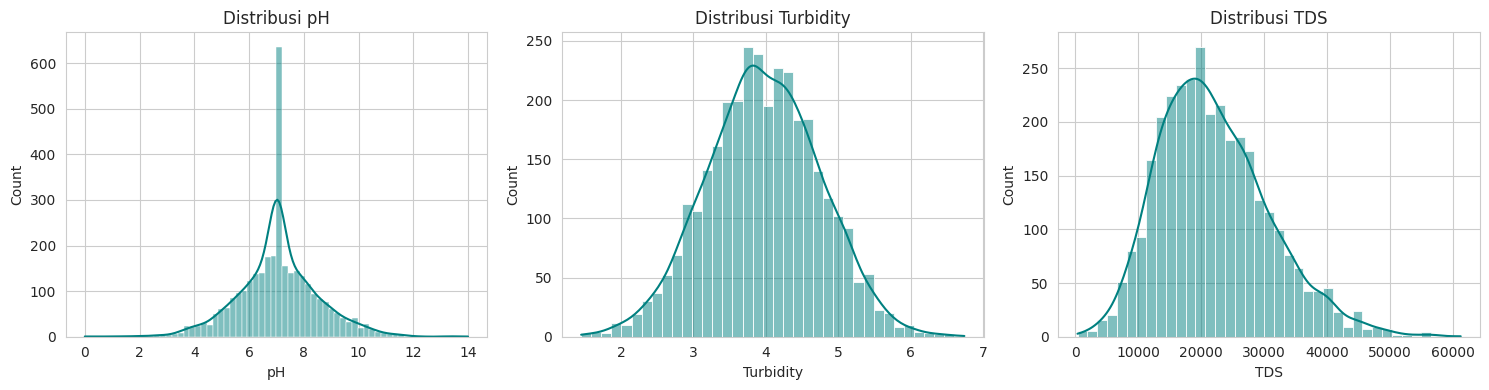

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
params = ['pH', 'Turbidity', 'TDS']
for ax, p in zip(axes, params):
    sns.histplot(df[p], kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribusi {p}')
plt.tight_layout()
plt.show()


### 4.4 Boxplot per Parameter terhadap Kategori

/tmp/ipykernel_514/2878296817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Kategori', y=p, order=order, ax=ax, palette='mako')
/tmp/ipykernel_514/2878296817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Kategori', y=p, order=order, ax=ax, palette='mako')
/tmp/ipykernel_514/2878296817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Kategori', y=p, order=order, ax=ax, palette='mako')


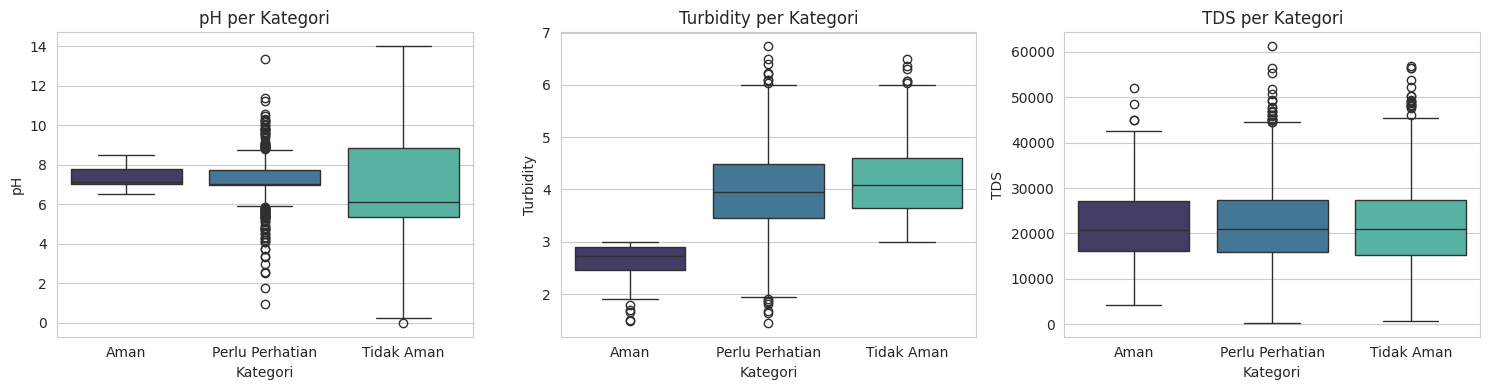

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, p in zip(axes, params):
    sns.boxplot(data=df, x='Kategori', y=p, order=order, ax=ax, palette='mako')
    ax.set_title(f'{p} per Kategori')
plt.tight_layout()
plt.show()


### 4.5 Korelasi Antar Parameter

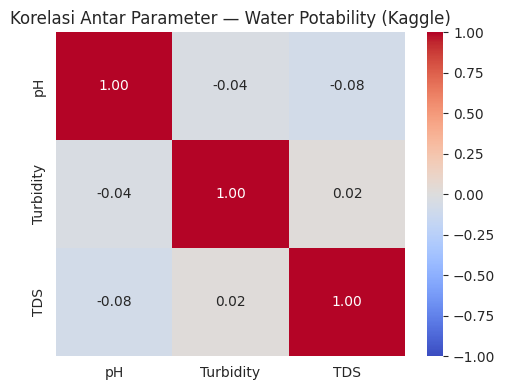

In [12]:
plt.figure(figsize=(5,4))
sns.heatmap(df[params].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Korelasi Antar Parameter — Water Potability (Kaggle)')
plt.tight_layout()
plt.show()


### 4.6 Catatan Temuan EDA — PENTING dibaca sebelum lanjut ke modeling

- Kolom `TDS` (dari `Solids`) **tidak sesuai skala mg/L standar** — dipakai sebagai fitur saja,
  tidak untuk pelabelan (lihat bagian 3.3).
- Distribusi kelas: "Aman" ±6%, "Perlu Perhatian" ±54%, "Tidak Aman" ±39% — lebih seimbang
  dibanding dataset fishpond, tapi kelas "Aman" tetap minoritas.
- Karena hanya 3 dari 4 parameter target tersedia (tidak ada Suhu), notebook ini sebaiknya
  diposisikan sebagai **pembanding/uji ketahanan model** terhadap dataset fishpond, bukan
  sumber training utama.

**Tahap selanjutnya:** train/test split (stratified) → training Random Forest → evaluasi →
bandingkan performa dengan model dari dataset fishpond.


## 5. Split Data (Train/Test)

Split dilakukan secara **stratified** (menjaga proporsi tiap kategori tetap sama di train & test),
penting karena distribusi kelas kita tidak seimbang (lihat temuan EDA di bagian 4.6).


In [13]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

X = df[['pH','Turbidity','TDS']]
y = df['Kategori']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('\nDistribusi kelas - Train:')
print(y_train.value_counts())
print('\nDistribusi kelas - Test:')
print(y_test.value_counts())


Train: (2620, 3) | Test: (656, 3)

Distribusi kelas - Train:
Kategori
Perlu Perhatian    1427
Tidak Aman         1033
Aman                160
Name: count, dtype: int64

Distribusi kelas - Test:
Kategori
Perlu Perhatian    357
Tidak Aman         259
Aman                40
Name: count, dtype: int64


## 6. Training Random Forest

`class_weight='balanced'` dipakai supaya model tidak mengabaikan kelas minoritas ("Aman") akibat
imbalance yang ditemukan di EDA. `n_estimators=200` dan `random_state=42` untuk hasil yang stabil
dan dapat direproduksi.


In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Model selesai dilatih.')


Model selesai dilatih.


## 7. Evaluasi Model

### 7.1 Classification Report

In [15]:
print(classification_report(y_test, y_pred))
print('Akurasi:', round(accuracy_score(y_test, y_pred), 4))
print('Macro F1-Score:', round(f1_score(y_test, y_pred, average='macro'), 4))


                 precision    recall  f1-score   support

           Aman       1.00      0.97      0.99        40
Perlu Perhatian       1.00      1.00      1.00       357
     Tidak Aman       1.00      1.00      1.00       259

       accuracy                           1.00       656
      macro avg       1.00      0.99      1.00       656
   weighted avg       1.00      1.00      1.00       656

Akurasi: 0.9985
Macro F1-Score: 0.9953


### 7.2 Confusion Matrix

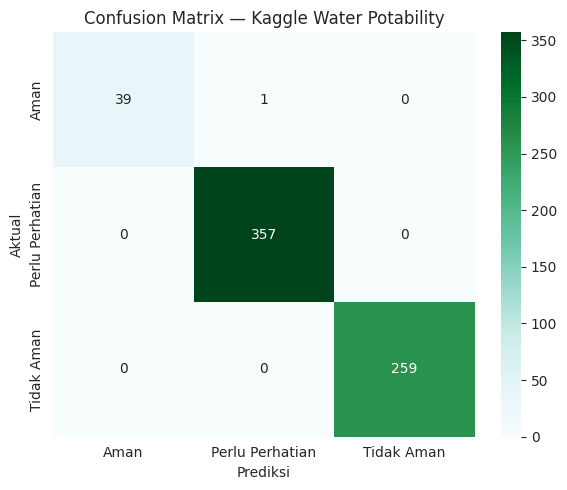

In [16]:
order = ['Aman', 'Perlu Perhatian', 'Tidak Aman']
cm = confusion_matrix(y_test, y_pred, labels=order)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn', xticklabels=order, yticklabels=order)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix — Kaggle Water Potability')
plt.tight_layout()
plt.show()


### 7.3 Validasi Silang (5-Fold Stratified Cross-Validation)

Karena kelas "Aman" jumlahnya sedikit, satu kali train/test split saja belum cukup meyakinkan.
Cross-validation memberi gambaran performa yang lebih stabil dengan merotasi data train/test
sebanyak 5 kali.


In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=skf, scoring='f1_macro')

print('Macro F1 tiap fold:', np.round(cv_scores, 4))
print(f'Rata-rata: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}')


Macro F1 tiap fold: [0.9989 1.     0.9989 1.     1.    ]
Rata-rata: 0.9996  |  Std: 0.0005


### 7.4 Feature Importance

/tmp/ipykernel_514/589809259.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='crest')


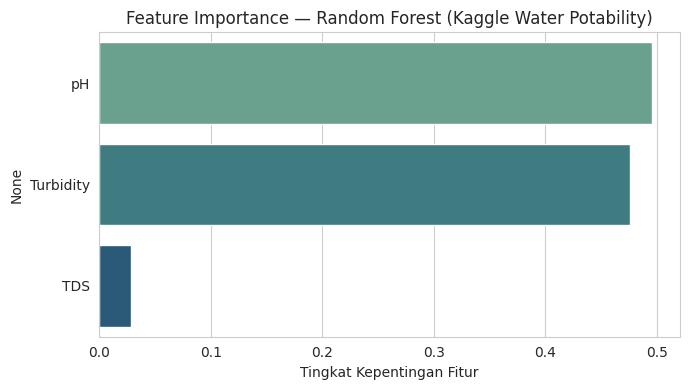

pH           0.495944
Turbidity    0.475515
TDS          0.028541
dtype: float64


In [18]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.title('Feature Importance — Random Forest (Kaggle Water Potability)')
plt.tight_layout()
plt.show()

print(importances)


### 7.5 Catatan Penting — Interpretasi Hasil

Akurasi dan F1-score yang sangat tinggi (mendekati/di atas 0,99) **bukan berarti model "sempurna"
memprediksi kualitas air sesungguhnya** — ini konsekuensi wajar karena label `Kategori` dibuat secara
*rule-based* langsung dari nilai pH, Turbidity itu sendiri (lihat bagian 3.3/3.4). Random Forest
pada dasarnya belajar merekonstruksi aturan ambang batas yang memang berbentuk pemisahan berbasis
threshold — jenis pola yang secara alami mudah dipelajari oleh model berbasis pohon keputusan.

Feature importance di atas justru jadi **sanity check yang baik**: fitur yang tidak dipakai dalam
aturan pelabelan seharusnya punya importance rendah — dan itu yang terlihat di hasil.

**Kegunaan model ini bukan untuk membuktikan akurasi tinggi**, tapi sebagai:
1. Basis bobot/pola untuk diuji terhadap **data lapangan nyata dari Sulahan** (uji generalisasi ke
   luar rule sederhana),
2. Pembanding metodologis antar dua sumber dataset (fishpond vs Kaggle) di bagian Hasil & Pembahasan.


## 8. Simpan Model (opsional)

In [19]:
import joblib

joblib.dump(rf, 'model_rf_{}.pkl'.format('{dataset_label}'.lower().replace(' ', '_')))
print('Model tersimpan.')


Model tersimpan.
